<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/01-market-risk/market_risk_EVT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

!pip install finance-datareader --quiet
import FinanceDataReader as fdr

df = fdr.DataReader('KS200', '2021-01-01', '2026-08-01')
df['Return'] = df['Close'].pct_change()
df = df.dropna()
losses = -df['Return']  # 손실을 양수로 다루기 위해 부호 반전
print(f"전체 관측일수: {len(losses)}일")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.0 MB/s eta 0:00:00
전체 관측일수: 1366일


관례적으로 손실을 양수로 다루는 EVT 사용. 수익률에 마이너스를 붙여 손실이 클 수록 큰 양수가 되도록 표현.

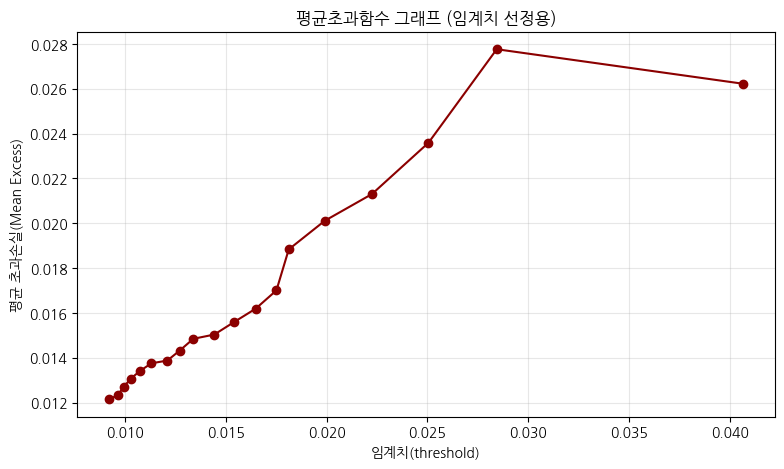

In [2]:
thresholds_grid = np.percentile(losses, np.arange(80, 99, 1))
mean_excess = []

for u in thresholds_grid:
    exceedances = losses[losses > u] - u
    mean_excess.append(exceedances.mean())

plt.figure(figsize=(9,5))
plt.plot(thresholds_grid, mean_excess, marker='o', color='darkred')
plt.xlabel('임계치(threshold)')
plt.ylabel('평균 초과손실(Mean Excess)')
plt.title('평균초과함수 그래프 (임계치 선정용)')
plt.grid(alpha=0.3)
plt.show()

GPD를 적용하려면 먼저 "어디서부터를 극단치로 볼 것인지" 임계치를 정해야 함.  이 그래프가 대략 직선 형태로 안정되기 시작하는 지점이 적절한 임계치. 너무 낮게 잡으면 극단치가 아닌 것까지 섞이고, 너무 높게 잡으면 표본이 부족해져서 추정이 불안정해지게 됨.

In [3]:
from scipy.stats import genpareto

threshold = np.percentile(losses, 95)  # 상위 5%를 극단치로 정의
exceedances = losses[losses > threshold] - threshold

print(f"임계치: {threshold:.4f}")
print(f"극단치(초과) 개수: {len(exceedances)}개 / 전체 {len(losses)}개")

shape, loc, scale = genpareto.fit(exceedances, floc=0)
print(f"\nGPD 추정 모수: shape(xi)={shape:.4f}, scale(beta)={scale:.4f}")

임계치: 0.0223
극단치(초과) 개수: 69개 / 전체 1366개

GPD 추정 모수: shape(xi)=0.3050, scale(beta)=0.0154


임계치는 우선 상위 5% 지점으로 설정. shape(형상모수)가 양수이면 꼬리가 두꺼운(fat tail) 분포라는 뜻 — 정규분포보다 극단치가 자주 나온다는 통계적 증거가 됨.

In [4]:
n = len(losses)
n_u = len(exceedances)

def evt_var(confidence, threshold, shape, scale, n, n_u):
    return threshold + (scale/shape) * (((n/n_u) * (1-confidence))**(-shape) - 1)

def evt_es(var, shape, scale, threshold):
    return (var + scale - shape*threshold) / (1 - shape)

for cl in [0.95, 0.99, 0.999]:
    var_evt = evt_var(cl, threshold, shape, scale, n, n_u)
    es_evt = evt_es(var_evt, shape, scale, threshold)
    print(f"신뢰수준 {cl*100}%  |  EVT VaR: {var_evt*100:.2f}%  |  EVT ES: {es_evt*100:.2f}%")

신뢰수준 95.0%  |  EVT VaR: 2.24%  |  EVT ES: 4.47%
신뢰수준 99.0%  |  EVT VaR: 5.45%  |  EVT ES: 9.09%
신뢰수준 99.9%  |  EVT VaR: 13.89%  |  EVT ES: 21.22%


GPD 모수를 이용해서 극단적 신뢰수준(95%, 99%, 심지어 99.9%)의 VaR과 ES를 직접 계산하는 공식. 특히 99.9%처럼 과거 데이터에 실제로 몇 개 없는 극단적인 신뢰수준도, GPD가 꼬리의 확률적 패턴을 학습했기 때문에 안정적으로 추정할 수 있는 게 EVT의 핵심 장점.

In [5]:
var_95_hist = np.percentile(losses, 95)
var_99_hist = np.percentile(losses, 99)

var_95_evt = evt_var(0.95, threshold, shape, scale, n, n_u)
var_99_evt = evt_var(0.99, threshold, shape, scale, n, n_u)

comparison = pd.DataFrame({
    'Historical': [var_95_hist, var_99_hist],
    'EVT(GPD)': [var_95_evt, var_99_evt]
}, index=['95% VaR', '99% VaR'])

print((comparison*100).round(2).astype(str) + '%')

        Historical EVT(GPD)
95% VaR      2.23%    2.24%
99% VaR      6.08%    5.45%


95%에서는 Historical과 EVT가 비슷하게 나올 수 있지만, 99% 이상으로 갈수록 두 값의 차이가 벌어지는 걸 확인하실 수 있음. 표본 데이터에 실제로 존재하는 극단치 개수가 적을수록 Historical 방식은 불안정해지는 반면, EVT는 분포의 형태를 학습했기 때문에 더 안정적인 추정을 제공함.

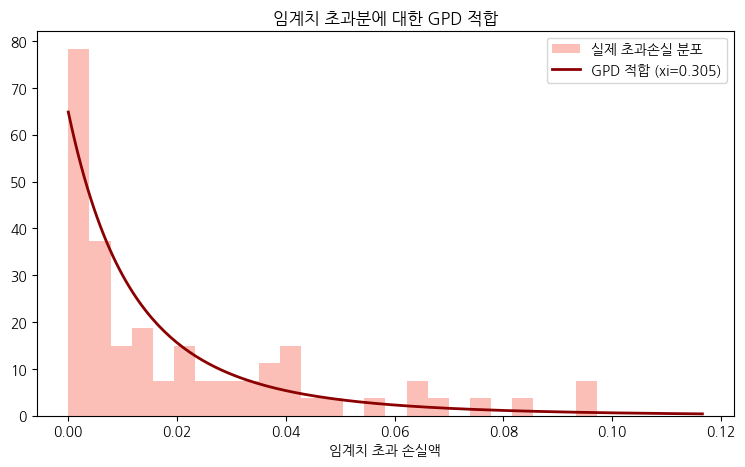

In [6]:
x = np.linspace(0, exceedances.max()*1.2, 200)
pdf_fitted = genpareto.pdf(x, shape, loc=0, scale=scale)

plt.figure(figsize=(9,5))
plt.hist(exceedances, bins=25, density=True, alpha=0.5, color='salmon', label='실제 초과손실 분포')
plt.plot(x, pdf_fitted, color='darkred', linewidth=2, label=f'GPD 적합 (xi={shape:.3f})')
plt.title('임계치 초과분에 대한 GPD 적합')
plt.xlabel('임계치 초과 손실액')
plt.legend()
plt.show()

실제 극단치 데이터와, 거기에 적합시킨 GPD 곡선을 겹쳐서 표현. 곡선이 실제 히스토그램을 잘 따라가면 GPD 가정이 타당하다는 뜻.

In [7]:
from scipy.stats import genpareto

percentile_range = np.arange(85, 99, 1)  # 상위 85%~98% 구간을 1%씩 이동하며 테스트
shapes = []
scales = []
n_exceedances_list = []

for p in percentile_range:
    u = np.percentile(losses, p)
    exc = losses[losses > u] - u
    if len(exc) > 10:  # 최소 표본 수 확보
        xi, _, beta = genpareto.fit(exc, floc=0)
        shapes.append(xi)
        scales.append(beta)
        n_exceedances_list.append(len(exc))
    else:
        shapes.append(np.nan)
        scales.append(np.nan)
        n_exceedances_list.append(len(exc))

shape_df = pd.DataFrame({
    '임계치_백분위': percentile_range,
    '극단치_개수': n_exceedances_list,
    'shape(xi)': shapes,
    'scale(beta)': scales
})
print(shape_df)

    임계치_백분위  극단치_개수  shape(xi)  scale(beta)
0        85     205   0.395310     0.008627
1        86     192   0.432054     0.008321
2        87     178   0.430170     0.008631
3        88     164   0.420759     0.009077
4        89     151   0.480067     0.008566
5        90     137   0.499677     0.008705
6        91     123   0.540291     0.008673
7        92     110   0.557755     0.009006
8        93      96   0.373361     0.012482
9        94      82   0.324372     0.014168
10       95      69   0.304950     0.015415
11       96      55   0.101372     0.021275
12       97      41  -0.245911     0.034910
13       98      28  -0.330080     0.035507


85%부터 98%까지 1%씩 임계치를 올려가면서, 그때마다 GPD를 다시 적합시켜 shape 값을 기록. 임계치가 높아질수록 극단치 개수는 줄어드는 걸 확인하실 수 있음.

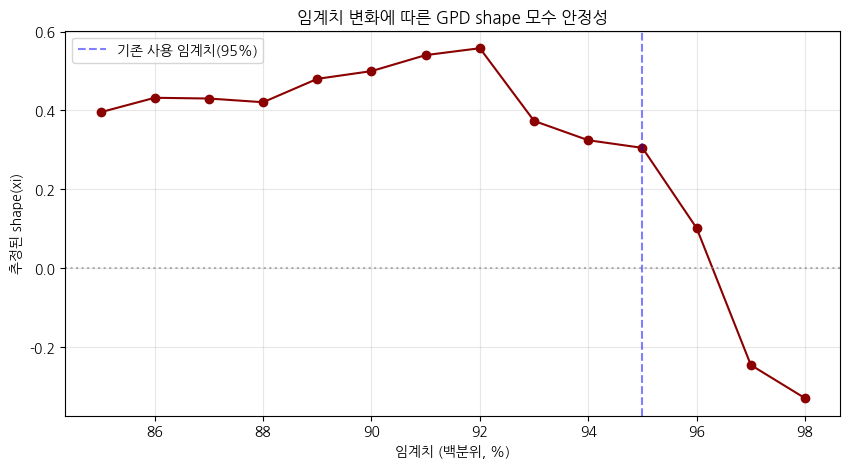

In [8]:
plt.figure(figsize=(10,5))
plt.plot(shape_df['임계치_백분위'], shape_df['shape(xi)'], marker='o', color='darkred')
plt.axhline(0, color='gray', linestyle=':', alpha=0.6)
plt.axvline(95, color='blue', linestyle='--', alpha=0.5, label='기존 사용 임계치(95%)')
plt.xlabel('임계치 (백분위, %)')
plt.ylabel('추정된 shape(xi)')
plt.title('임계치 변화에 따른 GPD shape 모수 안정성')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

만약 xi 값이 임계치를 바꿔도 특정 구간에서 평평하게(안정적으로) 유지된다면, "그 구간에서는 어떤 임계치를 골라도 결과가 크게 안 흔들린다"는 뜻이라 신뢰할 수 있음. 반대로 값이 위아래로 크게 요동친다면, 그 임계치 근처는 추정이 불안정하다는 신호.

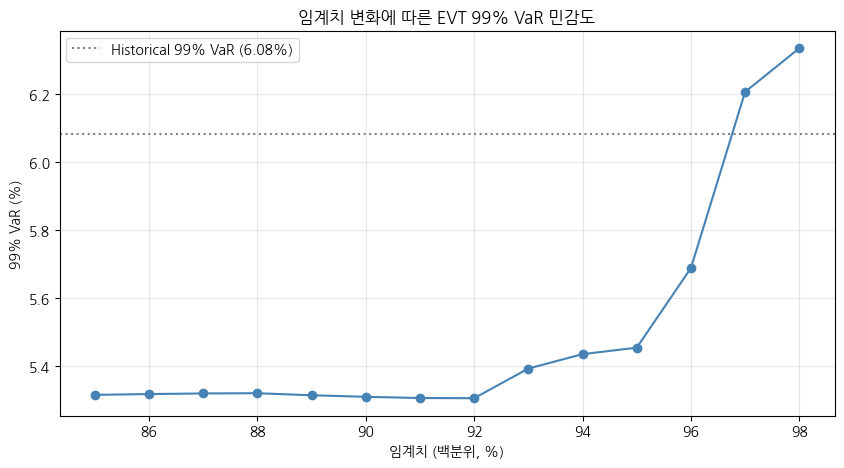

In [9]:
var_99_by_threshold = []

for p in percentile_range:
    u = np.percentile(losses, p)
    exc = losses[losses > u] - u
    if len(exc) > 10:
        xi, _, beta = genpareto.fit(exc, floc=0)
        n_u = len(exc)
        var99 = evt_var(0.99, u, xi, beta, n, n_u)
        var_99_by_threshold.append(var99)
    else:
        var_99_by_threshold.append(np.nan)

plt.figure(figsize=(10,5))
plt.plot(percentile_range, np.array(var_99_by_threshold)*100, marker='o', color='steelblue')
plt.axhline(var_99_hist*100, color='gray', linestyle=':', label=f'Historical 99% VaR ({var_99_hist*100:.2f}%)')
plt.xlabel('임계치 (백분위, %)')
plt.ylabel('99% VaR (%)')
plt.title('임계치 변화에 따른 EVT 99% VaR 민감도')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

shape뿐 아니라, 실제로 우리가 쓰려는 최종 결과물인 99% VaR 자체가 임계치에 따라 얼마나 흔들리는지 직접 보여줌. evt_var 함수는 아까 셀 4에서 정의한 함수를 그대로 재사용.